<a href="https://colab.research.google.com/github/luydkthptlequydon-sys/coluydaytin/blob/main/DEMO_ViT_ATTENTIONROLLOUT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install timm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import math
import copy
import random
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import timm
from torchvision import datasets, transforms

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

In [ ]:
# =========================
# CONFIG
# =========================
DATA_DIR = "/content/drive/MyDrive/MOD"
SAVE_DIR = "/content/drive/MyDrive/MOD_vit_results"

MODEL_NAME = "vit_small_patch16_224"
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
SEED = 42

os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

Device: cuda


In [ ]:
train_dir = os.path.join(DATA_DIR, "Train")
val_dir   = os.path.join(DATA_DIR, "Validation")
test_dir  = os.path.join(DATA_DIR, "Test")

print("Train dir exists:", os.path.exists(train_dir), train_dir)
print("Val dir exists  :", os.path.exists(val_dir), val_dir)
print("Test dir exists :", os.path.exists(test_dir), test_dir)

if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Không tìm thấy train_dir: {train_dir}")
if not os.path.exists(val_dir):
    raise FileNotFoundError(f"Không tìm thấy val_dir: {val_dir}")
if not os.path.exists(test_dir):
    raise FileNotFoundError(f"Không tìm thấy test_dir: {test_dir}")

Train dir exists: True /content/drive/MyDrive/MOD/Train
Val dir exists  : True /content/drive/MyDrive/MOD/Validation
Test dir exists : True /content/drive/MyDrive/MOD/Test


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=eval_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Num classes:", num_classes)
print("Train samples:", len(train_dataset))
print("Val samples  :", len(val_dataset))
print("Test samples :", len(test_dataset))

Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']
Num classes: 7
Train samples: 54
Val samples  : 55
Test samples : 407


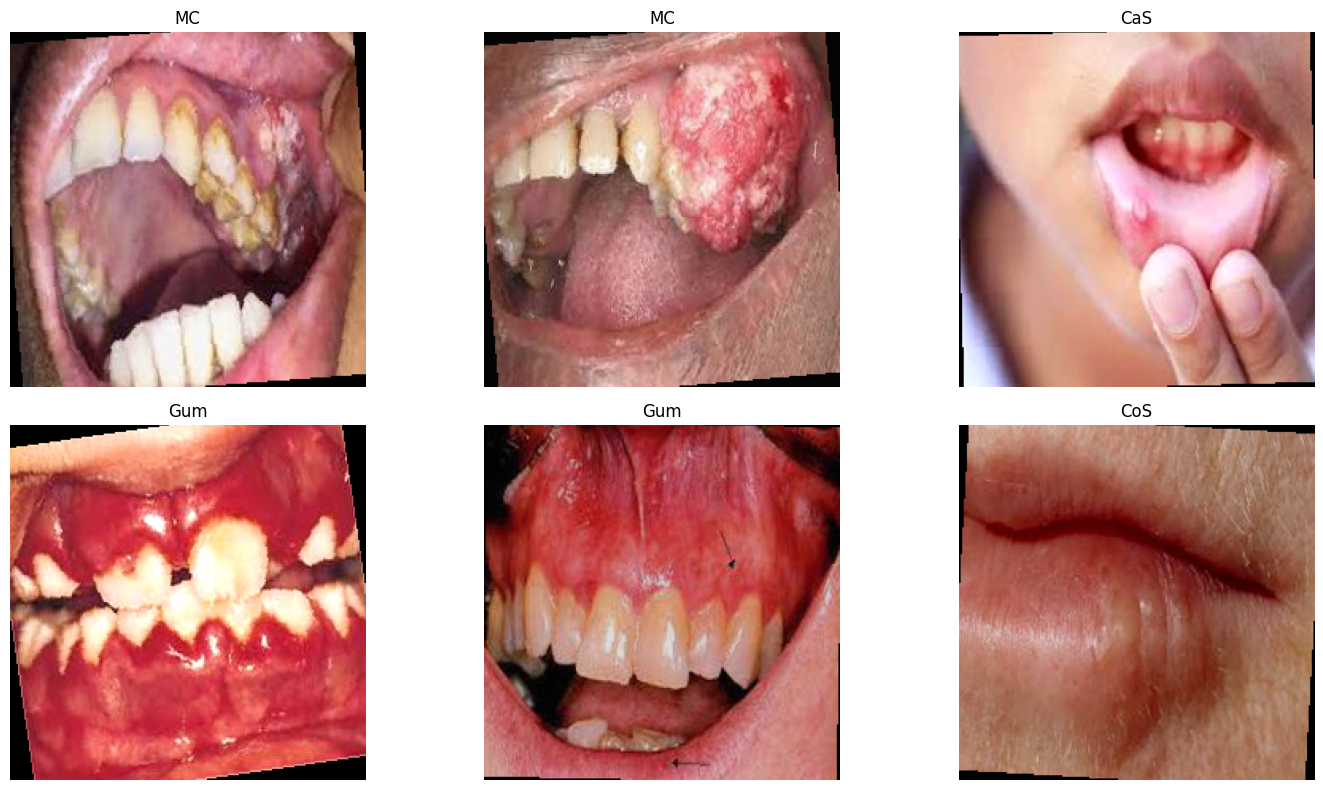

In [ ]:
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img

def show_batch(loader, class_names, n=6):
    images, labels = next(iter(loader))
    n = min(n, len(images))
    plt.figure(figsize=(15, 8))
    for i in range(n):
        plt.subplot(2, 3, i + 1)
        img = denormalize_image(images[i]).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[labels[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, class_names, n=6)

In [ ]:
def build_model(model_name, num_classes):
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=num_classes
    )

    # Tắt fused attention để có thể truy xuất attention ổn định hơn
    if hasattr(model, "blocks"):
        for block in model.blocks:
            if hasattr(block, "attn") and hasattr(block.attn, "fused_attn"):
                block.attn.fused_attn = False

    return model.to(DEVICE)

model = build_model(MODEL_NAME, num_classes)
print(model.__class__.__name__)
print("Has blocks:", hasattr(model, "blocks"))
print("Num blocks:", len(model.blocks) if hasattr(model, "blocks") else "N/A")

VisionTransformer
Has blocks: True
Num blocks: 12


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

checkpoint_path = os.path.join(SAVE_DIR, f"{MODEL_NAME}_best.pth")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({
            "model_name": MODEL_NAME,
            "model_state_dict": best_model_wts,
            "class_names": class_names
        }, checkpoint_path)
        print(f"==> Saved best model: {checkpoint_path}")

print("\nBest Val Acc:", best_val_acc)

model.load_state_dict(best_model_wts)

Epoch [1/10] | Train Loss: 2.1711 | Train Acc: 0.2037 | Val Loss: 1.9087 | Val Acc: 0.2909
==> Saved best model: /content/drive/MyDrive/MOD_vit_results/vit_small_patch16_224_best.pth
Epoch [2/10] | Train Loss: 1.3431 | Train Acc: 0.5185 | Val Loss: 1.7188 | Val Acc: 0.3818
==> Saved best model: /content/drive/MyDrive/MOD_vit_results/vit_small_patch16_224_best.pth
Epoch [3/10] | Train Loss: 0.9020 | Train Acc: 0.7407 | Val Loss: 1.5062 | Val Acc: 0.3818
Epoch [4/10] | Train Loss: 0.4504 | Train Acc: 0.8889 | Val Loss: 1.3843 | Val Acc: 0.4727
==> Saved best model: /content/drive/MyDrive/MOD_vit_results/vit_small_patch16_224_best.pth
Epoch [5/10] | Train Loss: 0.2051 | Train Acc: 0.9815 | Val Loss: 1.4255 | Val Acc: 0.4909
==> Saved best model: /content/drive/MyDrive/MOD_vit_results/vit_small_patch16_224_best.pth
Epoch [6/10] | Train Loss: 0.1279 | Train Acc: 1.0000 | Val Loss: 1.4322 | Val Acc: 0.5455
==> Saved best model: /content/drive/MyDrive/MOD_vit_results/vit_small_patch16_224_bes

<All keys matched successfully>

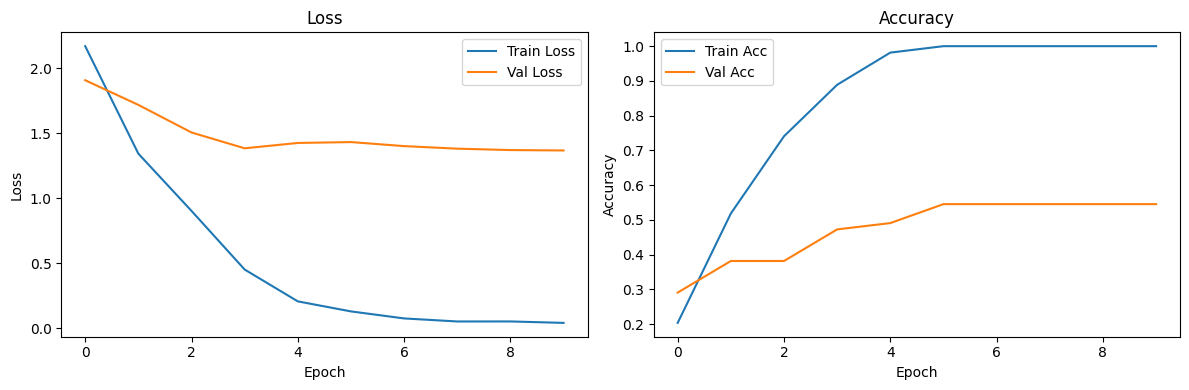

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def load_trained_model(checkpoint_path, model_name, num_classes):
    model = build_model(model_name, num_classes)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint["class_names"]

model, class_names = load_trained_model(checkpoint_path, MODEL_NAME, num_classes)
print("Loaded model from:", checkpoint_path)
print("Classes:", class_names)

Loaded model from: /content/drive/MyDrive/MOD_vit_results/vit_small_patch16_224_best.pth
Classes: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


In [ ]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())

    return np.array(all_labels), np.array(all_preds)

y_true, y_pred = predict_loader(model, test_loader)

test_acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")

Test Accuracy : 0.5258
Macro F1-score: 0.5053


In [ ]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)
print(report)

              precision    recall  f1-score   support

         CaS     0.5946    0.6984    0.6423        63
         CoS     0.6667    0.9153    0.7714        59
         Gum     0.5769    0.3191    0.4110        47
          MC     0.3750    0.5833    0.4565        72
          OC     0.4783    0.5238    0.5000        42
         OLP     0.5000    0.3378    0.4032        74
          OT     0.6667    0.2400    0.3529        50

    accuracy                         0.5258       407
   macro avg     0.5512    0.5168    0.5053       407
weighted avg     0.5438    0.5258    0.5077       407



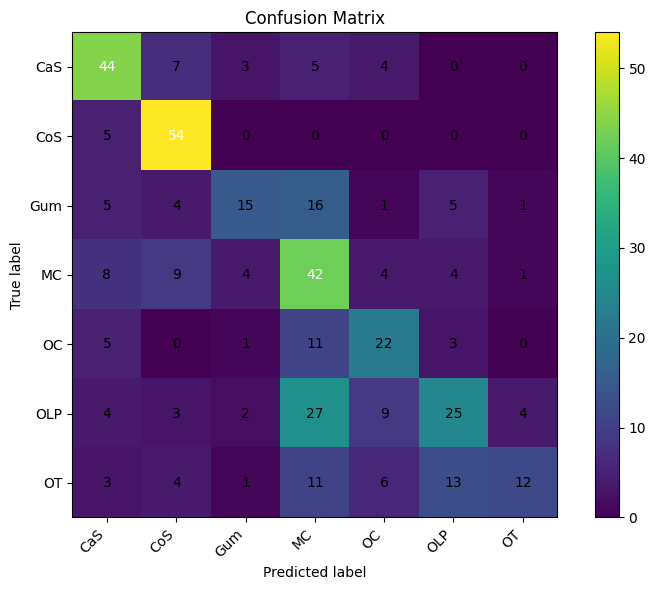

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

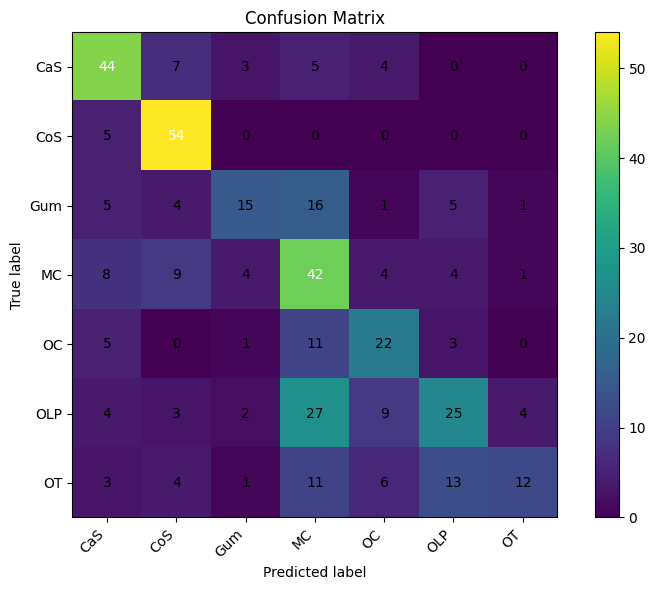

Saved confusion matrix to: /content/drive/MyDrive/MOD_vit_results/confusion_matrix.png


In [ ]:
cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], "d"),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix to:", cm_path)

In [ ]:
single_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

@torch.no_grad()
def predict_image(model, image_path, class_names):
    image = Image.open(image_path).convert("RGB")
    x = single_transform(image).unsqueeze(0).to(DEVICE)

    outputs = model(x)
    probs = torch.softmax(outputs, dim=1)
    pred_idx = torch.argmax(probs, dim=1).item()
    pred_class = class_names[pred_idx]
    pred_prob = probs[0, pred_idx].item()

    return image, x, pred_class, pred_prob, probs.cpu().numpy()[0]

In [ ]:
class VITAttentionRollout:
    def __init__(self, model, discard_ratio=0.0, head_fusion='mean'):
        self.model = model
        self.discard_ratio = discard_ratio
        self.head_fusion = head_fusion
        self.attentions = []
        self.hooks = []

        if not hasattr(self.model, "blocks"):
            raise ValueError("Model không có thuộc tính blocks. Hãy kiểm tra lại model ViT.")

        for block in self.model.blocks:
            self.hooks.append(
                block.attn.register_forward_pre_hook(self.get_attention_pre_hook)
            )

    def get_attention_pre_hook(self, module, inputs):
        x = inputs[0]  # [B, N, C]
        B, N, C = x.shape

        qkv = module.qkv(x)  # [B, N, 3*C]
        qkv = qkv.reshape(B, N, 3, module.num_heads, C // module.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # [3, B, heads, N, head_dim]

        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * module.scale
        attn = attn.softmax(dim=-1)  # [B, heads, N, N]

        self.attentions.append(attn.detach().cpu())

    def clear(self):
        self.attentions = []

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

    def rollout(self, input_tensor):
        self.clear()

        self.model.eval()
        with torch.no_grad():
            _ = self.model(input_tensor)

        if len(self.attentions) == 0:
            raise ValueError("Không thu được attention. Kiểm tra lại model hoặc hook.")

        num_tokens = self.attentions[0].size(-1)
        result = torch.eye(num_tokens)

        with torch.no_grad():
            for attention in self.attentions:
                attn = attention[0]  # [heads, tokens, tokens]

                if self.head_fusion == 'mean':
                    attn_fused = attn.mean(dim=0)
                elif self.head_fusion == 'max':
                    attn_fused = attn.max(dim=0)[0]
                elif self.head_fusion == 'min':
                    attn_fused = attn.min(dim=0)[0]
                else:
                    raise ValueError("head_fusion phải là 'mean', 'max' hoặc 'min'.")

                if self.discard_ratio > 0:
                    flat = attn_fused.view(-1)
                    num_keep = max(1, int(flat.size(0) * (1 - self.discard_ratio)))
                    _, indices = flat.topk(num_keep, largest=True)
                    mask = torch.zeros_like(flat)
                    mask[indices] = 1
                    attn_fused = (flat * mask).view(attn_fused.size())

                I = torch.eye(attn_fused.size(-1))
                a = attn_fused + I
                a = a / a.sum(dim=-1, keepdim=True)

                result = a @ result

        mask = result[0, 1:]  # CLS token -> patch tokens

        num_patches = mask.size(0)
        grid_size = int(math.sqrt(num_patches))
        if grid_size * grid_size != num_patches:
            raise ValueError(f"Số patch {num_patches} không tạo được lưới vuông.")

        mask = mask.reshape(grid_size, grid_size).numpy()
        mask = mask / (mask.max() + 1e-8)

        return mask

In [ ]:
def show_attention_rollout(model, image_path, class_names,
                           discard_ratio=0.1, head_fusion='mean', alpha=0.5):
    image, x, pred_class, pred_prob, probs = predict_image(model, image_path, class_names)

    rollout = VITAttentionRollout(
        model=model,
        discard_ratio=discard_ratio,
        head_fusion=head_fusion
    )

    mask = rollout.rollout(x)
    rollout.remove_hooks()

    image_resized = image.resize((IMG_SIZE, IMG_SIZE))
    image_np = np.array(image_resized).astype(np.float32) / 255.0

    mask_img = Image.fromarray((mask * 255).astype(np.uint8)).resize(
        (IMG_SIZE, IMG_SIZE),
        resample=Image.BILINEAR
    )
    mask_np = np.array(mask_img).astype(np.float32) / 255.0

    cmap = plt.get_cmap("jet")
    heatmap = cmap(mask_np)[:, :, :3]

    overlay = (1 - alpha) * image_np + alpha * heatmap
    overlay = np.clip(overlay, 0, 1)

    top3_idx = np.argsort(probs)[::-1][:3]

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image_np)
    plt.title("Ảnh gốc")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="jet")
    plt.title("Attention Rollout")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    title_text = f"Dự đoán: {pred_class}\nXác suất: {pred_prob:.4f}"
    plt.title(title_text)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    print("Top-3 predictions:")
    for idx in top3_idx:
        print(f"  {class_names[idx]}: {probs[idx]:.4f}")

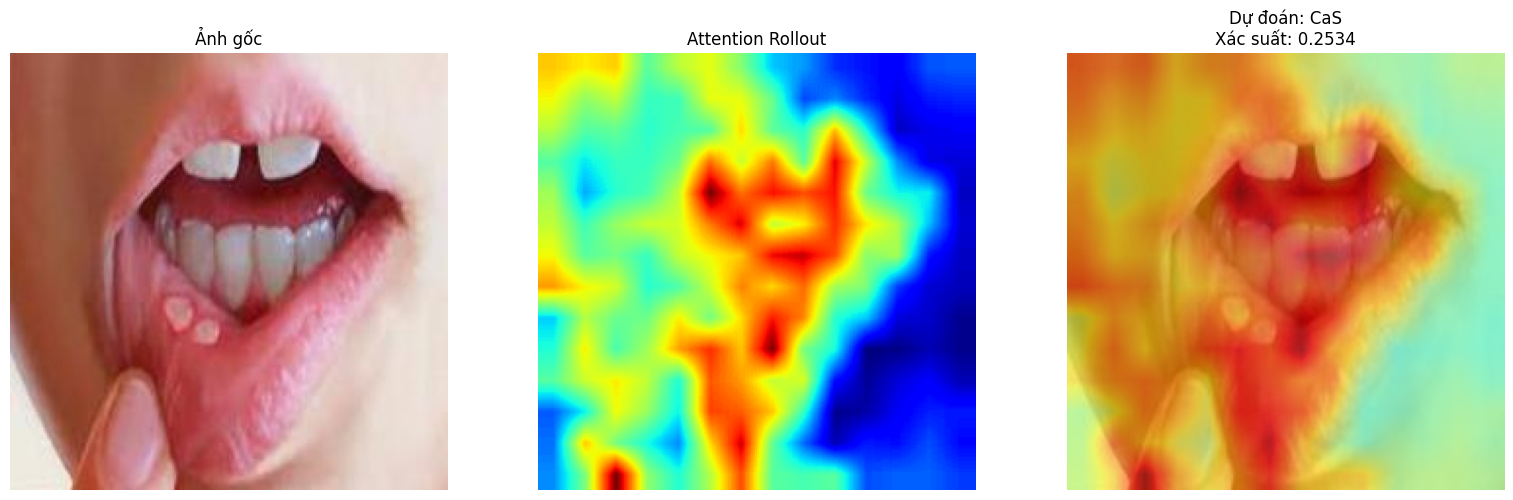

Top-3 predictions:
  CaS: 0.2534
  MC: 0.2353
  CoS: 0.2262


In [ ]:
sample_image_path = "/content/drive/MyDrive/MOD/Test/CaS/_462.jpg"

show_attention_rollout(
    model=model,
    image_path=sample_image_path,
    class_names=class_names,
    discard_ratio=0.1,
    head_fusion='mean',
    alpha=0.55
)


Image: /content/drive/MyDrive/MOD/Test/Gum/_445.jpg


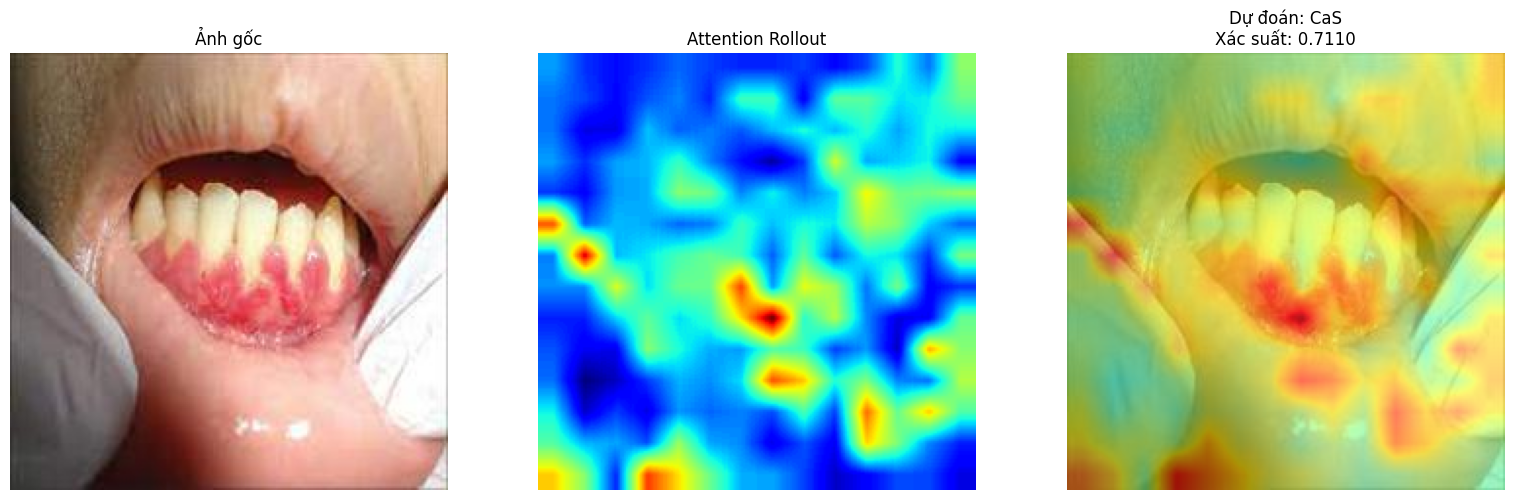

Top-3 predictions:
  CaS: 0.7110
  OC: 0.0677
  MC: 0.0665

Image: /content/drive/MyDrive/MOD/Test/CaS/_452.jpg


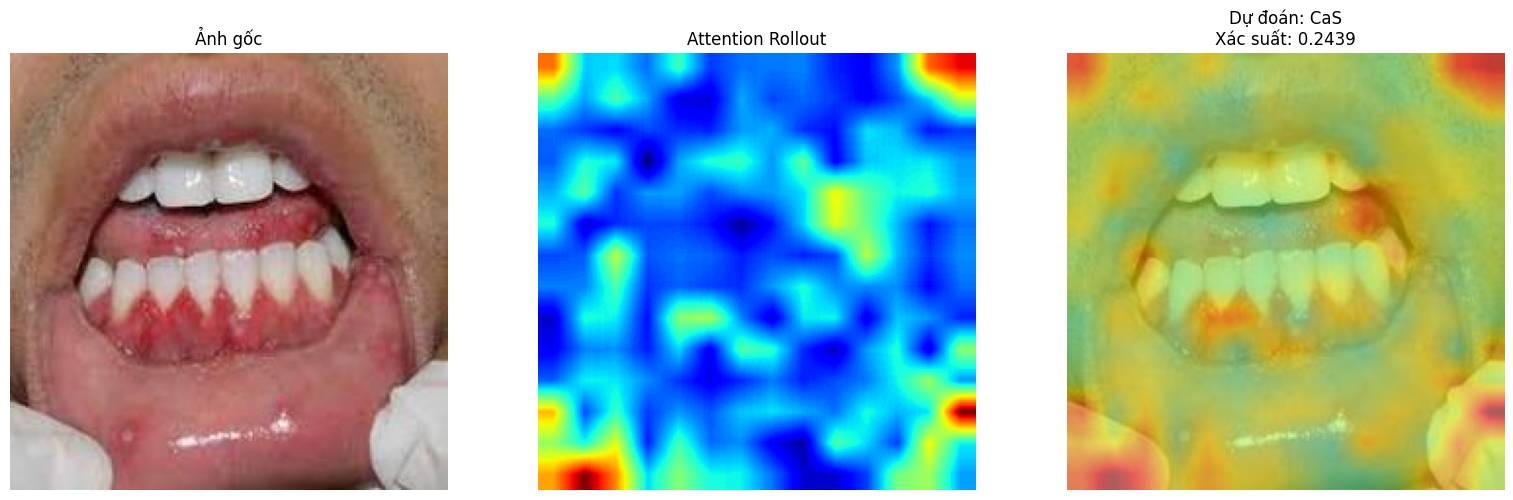

Top-3 predictions:
  CaS: 0.2439
  Gum: 0.1960
  CoS: 0.1785

Image: /content/drive/MyDrive/MOD/Test/OT/_449.jpg


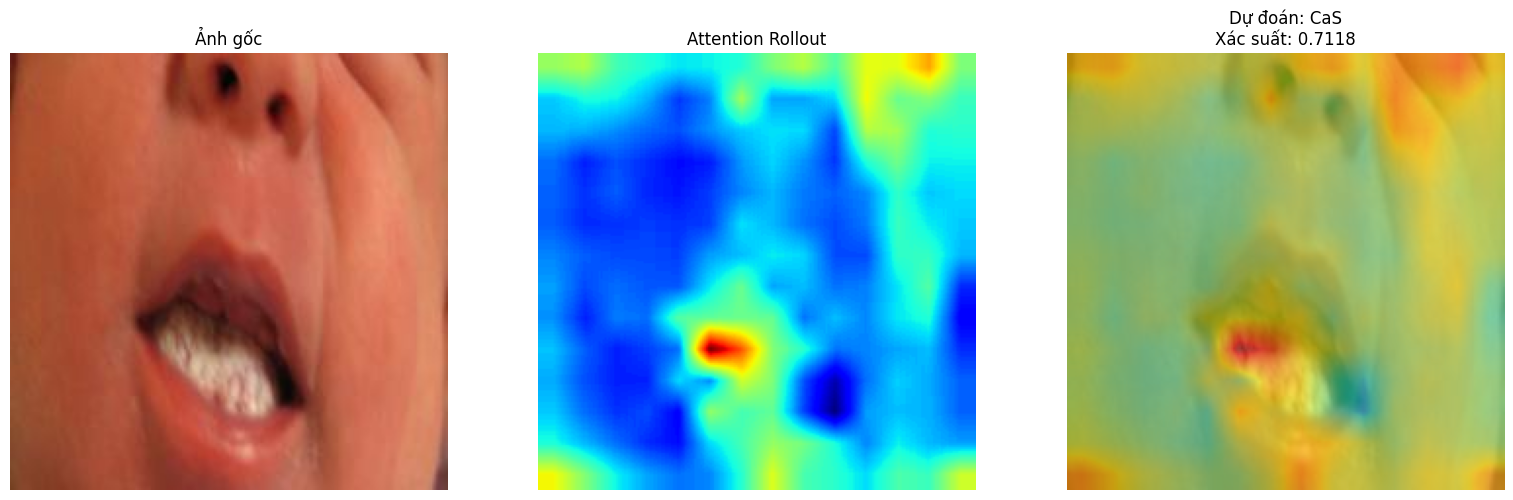

Top-3 predictions:
  CaS: 0.7118
  CoS: 0.0985
  MC: 0.0922


In [ ]:
import glob

def get_all_images(root_dir):
    all_images = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]:
        all_images.extend(glob.glob(os.path.join(root_dir, "*", ext)))
    return all_images

def show_random_test_samples(model, test_root, class_names, n=3):
    all_images = get_all_images(test_root)
    if len(all_images) == 0:
        print("Không tìm thấy ảnh trong tập test.")
        return

    sample_paths = random.sample(all_images, min(n, len(all_images)))

    for path in sample_paths:
        print("\nImage:", path)
        show_attention_rollout(
            model=model,
            image_path=path,
            class_names=class_names,
            discard_ratio=0.1,
            head_fusion='mean',
            alpha=0.55
        )

show_random_test_samples(model, test_dir, class_names, n=3)